# Usecase
Fine-tune a language model for the pharmaceutical domain using a multi-stage training strategy. The model is first adapted to pharmaceutical knowledge through unsupervised fine-tuning on domain-specific PDF documents, enabling it to learn terminology, context, and domain semantics. Next, supervised instruction-based fine-tuning is applied to train the model to follow domain-specific instructions and produce reliable, structured outputs. Finally, preference-based fine-tuning is used to further align the model’s responses with desired quality standards, tone, and domain-specific expectations.

#### Fine-tuning Strategy

The fine-tuning process consists of three stages:

1. **Unsupervised Fine-tuning (Domain Adaptation)**
    Leverages unlabeled pharmaceutical documents to build foundational domain understanding.

2. **Instruction Fine-tuning (Structured Output – Supervised)**
    Trains the model on labeled, instruction–response pairs to generate consistent and structured outputs.

3. **Preference-based Fine-tuning (Alignment)**
    Optimizes the model using preference signals to improve response quality, relevance, and adherence to domain expectations.

**Note**: We will use the Llama model for this finetunning.

In [50]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Import Libraries
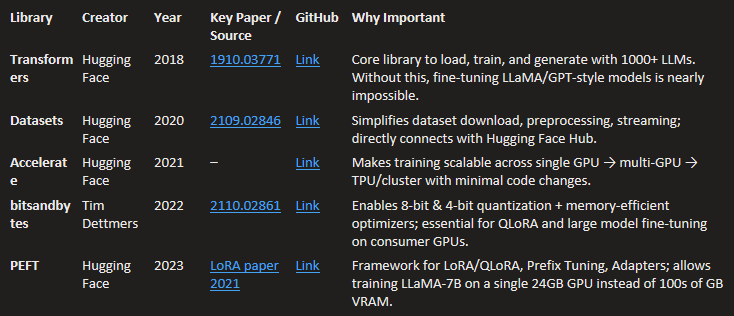

In [51]:
!pip install -U peft bitsandbytes transformers accelerate

In [52]:
!pip install -U trl  #transformer reinforecement learning

In [53]:
!pip install PyMuPDF

In [54]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()


False

In [55]:
# base_model_name = "meta-llama/Llama-2-7b-hf"
# base_model_name = "meta-llama/Llama-3.1-8B"
# base_model_name = "microsoft/phi-2"

base_model_name = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
ft_model_name = "tinyllama-pharma-unsupervised"
models_dir = "/content/drive/MyDrive/models"
output_dir = f"{models_dir}/{ft_model_name}"

In [56]:
# supress tensorflow warnings
# HF uses tensorflow if it's installed, even if you're using PyTorch
! export TRANSFORMERS_NO_TF=1

In [57]:
# Import necessary libraries
import fitz
import re
import tf_keras as keras
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments
from peft import LoraConfig, get_peft_model, TaskType


# Stage1 - Unsupervised Finetuning (for Domain Adaptation)

### Step1: Data Preprocessing

In [58]:
import fitz

def extract_text_from_pdf(pdf_path):
    text_blocks = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text = page.get_text("text").strip()
            if text:
                text_blocks.append(text)
    return text_blocks

In [59]:
#pdf_texts = extract_text_from_pdf("../../_data/Metformin.pdf")
# pdf_texts = extract_text_from_pdf("/content/drive/MyDrive/buildllm/_data/Metformin.pdf")
pdf_texts = extract_text_from_pdf("/content/drive/MyDrive/buildllm/_data/essential-drugs.pdf")

| Model                        | Max Context Window (chunk length) during training | Approx words     | Comment                                                            |
| ---------------------------- | ------------------------------------------------- | ---------------- | ------------------------------------------------------------------ |
| **GPT-1 (2018)**             | 512 tokens                                        | ~350 words       | First transformer LM, small context                                |
| **GPT-2 (2019)**             | 1,024 tokens                                      | ~750 words       | Larger context for smoother coherence                              |
| **GPT-3 (2020)**             | 2,048 tokens                                      | ~1.5k words      | Trained on 300 B tokens with this window                           |
| **GPT-3.5 / ChatGPT (2022)** | 4,096 tokens                                      | ~3k words        | Used mixture of 2k–4k during pretraining + instruction fine-tuning |
| **GPT-4 (2023)**             | 8,192 – 32,768 – 1,28,000 tokens*                            | up to ~25k to 1L words | Multi-context variants (8k & 32k models)                           |

**Note**: Models have defined context-window. The input text must not exceed the context widnow. Hence, the pdf text must be broken down into chunks.

| Step                                     | What Happens                                                                             | Example                                     |
| ---------------------------------------- | ---------------------------------------------------------------------------------------- | ------------------------------------------- |
| **1️⃣ Data Collection**                  | Crawl text from web (Wikipedia, CommonCrawl, Books, PubMed, Code, etc.)                  | Billions of documents                       |
| **2️⃣ Cleaning / Filtering**             | Remove HTML, junk, duplicates, low-quality content                                       | Similar to your `strip()` & len filter      |
| **3️⃣ Splitting / Chunking**             | Split into paragraphs / segments using regex rules, sentence boundaries, or token length | Like your `re.split(r'\n\s*\n')`            |
| **4️⃣ Tokenization**                     | Convert text chunks → token IDs using BPE                                                | “The cat” → `[1012, 52, 199]`               |
| **5️⃣ Training (Next-Token Prediction)** | Model learns to predict the next token in each chunk                                     | Input: “The cat sat on the” → Target: “mat” |

In [60]:
import re
def split_paragraphs(pages):
    paragraphs = []
    for page_text in pages:
        # Split on double line breaks or long newlines
        chunks = re.split(r'\n\s*\n', page_text)
        for chunk in chunks:
            clean = chunk.strip()
            if len(clean) > 30:  # ignore too short lines
                paragraphs.append(clean)
    return paragraphs

In [61]:
paragraphs = split_paragraphs(pdf_texts)

In [62]:
data = [{"text": p} for p in paragraphs]
print(f"Extracted {len(data)} paragraphs from the PDF.")
print(data)

Extracted 1778 paragraphs from the PDF.
[{'text': 'Page 1 / 663\nExported on: 15/10/2025\nEssential drugs\nPractical guide intended for physicians, pharmacists, nurses and medical\nauxiliaries'}, {'text': 'Page 2 / 663\nISBN\nAll rights reserved for all countries. No reproduction, translation and adaptation may be done without\nthe prior permission of the Copyright owner.\nMédecins Sans Frontières. Essential drugs - practical guidelines.\nJuly 2025\n978-2-37585-280-4'}, {'text': 'Page 3 / 663\nTable of contents\nAuthors/Contributors\nPreface\nForeword\nUse of the guide\nAbbreviations and acronyms\nOral drugs\nInjectable drugs\nInfusion fluids\nVaccines, immunoglobulins and antisera\nDrugs for external use, antiseptics and disinfectants\nDrugs potentially dangerous or obsolete or ineffective\nPart two\nMain references'}, {'text': 'Page 4 / 663\nAuthors/Contributors'}, {'text': 'Essential drugs\xa0\u202fhas\u202fbeen developed by Médecins Sans Frontières.'}, {'text': 'MSF would like to e

In [63]:
from datasets import Dataset, load_dataset

dataset = Dataset.from_list(data)

dataset

Dataset({
    features: ['text'],
    num_rows: 1778
})

In [64]:
tokenizer = AutoTokenizer.from_pretrained(base_model_name)

In [65]:
# Its needed to pad all sequences to make them of same length
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

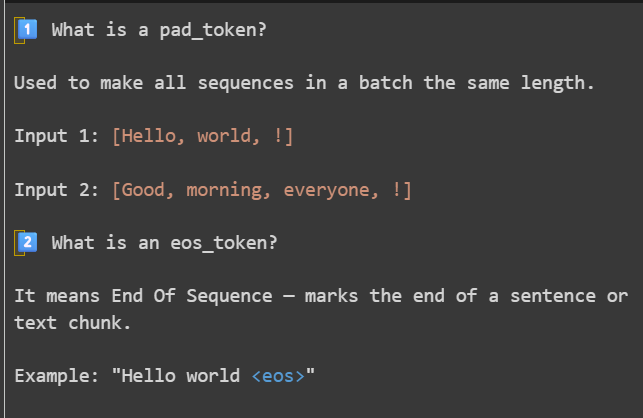

In [66]:
def tokenize_fn(examples):
    tokens = tokenizer(examples["text"],truncation=True,padding="max_length",max_length=512)
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

In [67]:
tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])

Map:   0%|          | 0/1778 [00:00<?, ? examples/s]

In [68]:
tokenized

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1778
})

### Step2: Model Quantization & LoRA setup

In [69]:
# download 8-bit quantized model
model_q = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    load_in_8bit=True,
    device_map="auto"
)
model_q.eval()

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear8bitLt(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear8bitLt(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear8bitLt(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear8bitLt(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm):

In [70]:
# ingest lora adaptor into the model.
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    target_modules=["q_proj","v_proj"],
    lora_dropout=0.05,
    bias="none"
)

qlora_model = get_peft_model(model_q, lora_config)

qlora_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear8bitLt(
                (base_layer): Linear8bitLt(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Li

### Step3: Model Training

In [71]:
args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_total_limit=1,
    report_to="none"
)

In [72]:
trainer = Trainer(
    model=qlora_model,
    args=args,
    train_dataset=tokenized
)

In [73]:
trainer.train()

Step,Training Loss
20,7.003200
40,0.798100
60,0.487700
80,0.447400
100,0.495300
120,0.386800
140,0.426400
160,0.392100
180,0.370300
200,0.408500


Step,Training Loss
20,7.003200
40,0.798100
60,0.487700
80,0.447400
100,0.495300
120,0.386800
140,0.426400
160,0.392100
180,0.370300
200,0.408500


TrainOutput(global_step=1115, training_loss=0.48264771619719776, metrics={'train_runtime': 2129.8874, 'train_samples_per_second': 4.174, 'train_steps_per_second': 0.524, 'total_flos': 2.828337804214272e+16, 'train_loss': 0.48264771619719776, 'epoch': 5.0})

### Step4: Model Evaluation

In [78]:
model_path = f"{output_dir}/checkpoint-1115"

In [79]:
model = AutoModelForCausalLM.from_pretrained(model_path, device_map="auto")

In [84]:
prompt = "Determine the correct oral dosage of Amoxicillin for a child weighing 10 kg with tonsillitis."

In [85]:
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [86]:
outputs = model.generate(
    **inputs,
    max_new_tokens=100,
    temperature=0.8,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.1
)

In [87]:
print("\nModel Output:\n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Model Output:

Determine the correct oral dosage of Amoxicillin for a child weighing 10 kg with tonsillitis.
If the amount given is too small, increase the dose until the patient is symptomatically better.


### Step5: Zip and Store the Model

In [ ]:
import shutil
from pathlib import Path

def zip_model(model_dir, output_zip):
    model_dir = Path(model_dir)
    output_zip = Path(output_zip)

    # shutil.make_archive expects path WITHOUT .zip
    shutil.make_archive(
        base_name=output_zip.with_suffix(""),
        format="zip",
        root_dir=model_dir.parent,
        base_dir=model_dir.name
    )

# Example
zip_model(
    model_dir=output_dir,
    output_zip=f"{models_dir}/{ft_model_name}.zip"
)